In [107]:
!uv pip install dscribe

Using Python 3.12.13 environment at: c:\Users\asros\miniconda3\envs\cms
Audited 1 package in 32ms


## The Coulomb Matrix Formula

For a molecule with $N$ atoms, the Coulomb matrix $\mathbf{C}$ is $N \times N$:

$$
C_{ij} = \begin{cases}
  0.5\, Z_i^{2.4} & i = j \\[6pt]
  \dfrac{Z_i\, Z_j}{|\mathbf{R}_i - \mathbf{R}_j|} & i \neq j
\end{cases}
$$

- **Diagonal** — encodes _what atom_ this is (based on $Z$ = atomic number)
- **Off-diagonal** — encodes _how close_ two atoms are, weighted by their charges (like nuclear repulsion)

To use as an ML input, we create 1D vector representation of $\mathbf{C}$ that doesn't change if you reorder the atoms.


# Manual Demo

Since this is pretty easy to code up ourselves, we will manually create the Coulomb Matrix and display it for a representative molecule.


In [108]:
import numpy as np


def get_coulomb(mol):
    """Return the raw N×N Coulomb matrix."""
    Z = mol.get_atomic_numbers()
    pos = mol.get_positions()
    N = len(Z)
    C = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            if i == j:
                C[i, j] = 0.5 * Z[i] ** 2.4
            else:
                C[i, j] = Z[i] * Z[j] / np.linalg.norm(pos[i] - pos[j])
    return C


Let's start by viewing the Coulomb matrix of C60.


In [109]:
from ase.build import molecule
from ase.visualize import view

mol = molecule("C60")
view(mol, viewer="x3d")

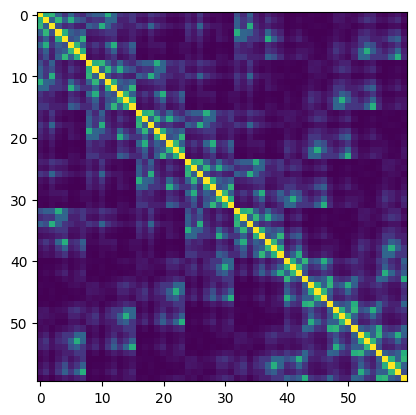

In [110]:
import matplotlib.pyplot as plt

C = get_coulomb(mol)
plt.imshow(C)

Now it's your turn. Take a minute to construct Coulomb matrices using the example molecules available with `ase.build.molecule` as shown [here](https://ase-lib.org/ase/build/build.html#ase.build.molecule). Can you rationalize any of the features that appear in the Coulomb matrix?


In [111]:
# your code here

# DScribe


There is a code `dscribe` that contains several structural feature generation routines. We can call it directly. Let's consider the following molecules: H2, H2O, NH3, and C60.


In [112]:
molecules = [molecule("H2"), molecule("H2O"), molecule("NH3"), molecule("C60")]
max_N = max([len(mol) for mol in molecules])

In [113]:
from dscribe.descriptors import CoulombMatrix

cm = CoulombMatrix(n_atoms_max=max_N, permutation="eigenspectrum")

for mol in molecules:
    C = cm.create(mol)
    print(mol)
    print(C)

Atoms(symbols='H2', pbc=False)
[ 1.85654656 -0.85654656  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.        ]
Atoms(symbols='OH2', pbc=False)
[75.35554313 -0.68374562 -0.15510279  0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.  

# Reproducing a Paper

In this exercise, we will reproduce the resuls of the original [Coulomb matrix paper](https://link.aps.org/doi/10.1103/PhysRevLett.108.058301). Specifically, we will aim to predict the atomization energy of small organic molecules in the QM7 dataset.


First, we need to load in the dataset.


In [114]:
import os
import urllib.request
from ase.atoms import Atoms

url = "http://quantum-machine.org/data/qm7.mat"
filename = "qm7.mat"

if not os.path.exists(filename):
    print("Downloading QM7 dataset...")
    urllib.request.urlretrieve(url, filename)
# Load dataset
from scipy.io import loadmat

data = loadmat(filename)
R = data["R"]  # atomic coordinates
Z = data["Z"]  # atomic numbers
y = data["T"].reshape(-1)  # atomization energies

atoms = []
for i in range(len(y)):
    mask = Z[i] > 0
    positions = R[i][mask]
    numbers = Z[i][mask]

    atoms.append(Atoms(numbers=numbers, positions=positions))

In [115]:
print(len(atoms))
print(len(y))

7165
7165


Text(0, 0.5, 'Count')

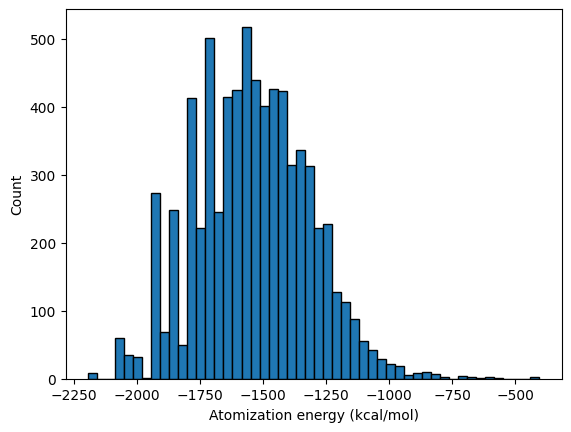

In [116]:
import matplotlib.pyplot as plt

plt.hist(y, bins=50, edgecolor="k")
plt.xlabel("Atomization energy (kcal/mol)")
plt.ylabel("Count")

Now we will construct the Coulomb matrices using dscribe.


In [117]:
max_atoms = max([len(mol) for mol in atoms])
cm = CoulombMatrix(n_atoms_max=max_atoms, permutation="eigenspectrum")
X = cm.create(atoms, n_jobs=-1)


In [118]:
X.shape

(7165, 23)

Now let's reproduce Figure 1a in the paper, in which we calculate the Euclidean distance metric for each pair of molecules.


In [119]:
from sklearn.metrics import pairwise_distances

D = pairwise_distances(X, metric="euclidean", n_jobs=-1)

Text(0, 0.5, 'Frequency')

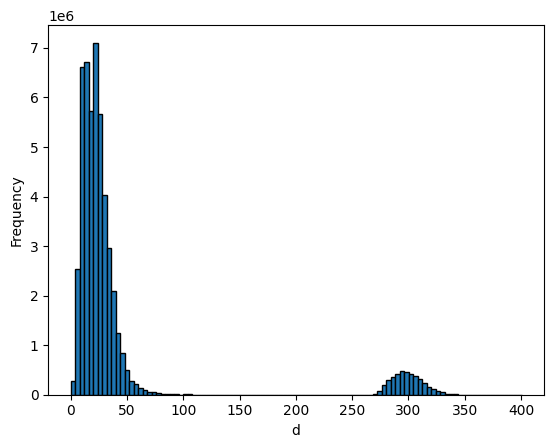

In [120]:
plt.hist(D.flatten(), bins=100, edgecolor="k")
plt.xlabel("d")
plt.ylabel("Frequency")

Now let's use the flattened Coulomb matrices to train a KRR model.


In [121]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [122]:
from sklearn.kernel_ridge import KernelRidge

model = KernelRidge(kernel="rbf", alpha=1e-5, gamma=1e-3)

model.fit(X_train, y_train)


,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`. If an array is passed, penalties areassumed to be specific to the targets. Hence they must correspond innumber. See :ref:`ridge_regression` for formula.",1e-05
,"kernel kernel: str or callable, default=""linear""Kernel mapping used internally. This parameter is directly passed to:class:`~sklearn.metrics.pairwise.pairwise_kernels`.If `kernel` is a string, it must be one of the metricsin `pairwise.PAIRWISE_KERNEL_FUNCTIONS` or ""precomputed"".If `kernel` is ""precomputed"", X is assumed to be a kernel matrix.Alternatively, if `kernel` is a callable function, it is called oneach pair of instances (rows) and the resulting value recorded. Thecallable should take two rows from X as input and return thecorresponding kernel value as a single number. This means thatcallables from :mod:`sklearn.metrics.pairwise` are not allowed, asthey operate on matrices, not single samples. Use the stringidentifying the kernel instead.",'rbf'
,"gamma gamma: float, default=NoneGamma parameter for the RBF, laplacian, polynomial, exponential chi2and sigmoid kernels. Interpretation of the default value is left tothe kernel; see the documentation for sklearn.metrics.pairwise.Ignored by other kernels.",0.001
,"degree degree: float, default=3Degree of the polynomial kernel. Ignored by other kernels.",3
,"coef0 coef0: float, default=1Zero coefficient for polynomial and sigmoid kernels.Ignored by other kernels.",1
,"kernel_params kernel_params: dict, default=NoneAdditional parameters (keyword arguments) for kernel function passedas callable object.",None


In [123]:
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print(f"Test MAE: {mae} kcal/mol")


Test MAE: 9.83808696159565 kcal/mol


Now we reproduce the parity plot in Figure 2b.


Text(0.5, 0, 'E_ref (kcal/mol)')

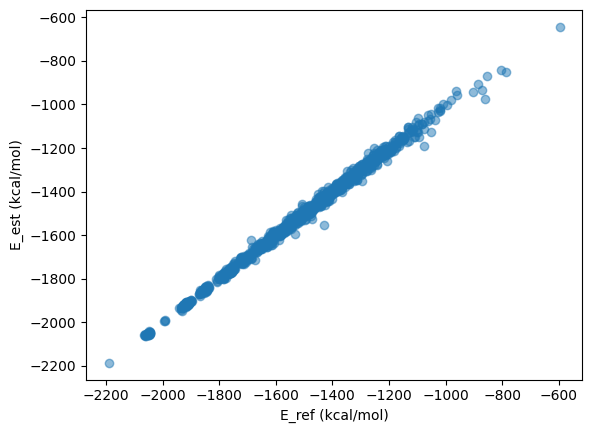

In [126]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.ylabel("E_est (kcal/mol)")
plt.xlabel("E_ref (kcal/mol)")

# Exercise

1. Try varying the hyperparameters. Can you find better ones?
2. Try to reproduce the learning curve shown in Figure 2a. Note that the x-axis is actually N, not log2(N). The spacing is just on a log spacing.


Train size: 500, Test MAE: 26.702739638741217 kcal/mol
Train size: 1081, Test MAE: 19.3123423874108 kcal/mol
Train size: 1662, Test MAE: 14.642385667367376 kcal/mol
Train size: 2244, Test MAE: 13.27971779534995 kcal/mol
Train size: 2825, Test MAE: 11.657195388339188 kcal/mol
Train size: 3406, Test MAE: 11.243722983347295 kcal/mol
Train size: 3988, Test MAE: 10.507346801134508 kcal/mol
Train size: 4569, Test MAE: 10.120256881392601 kcal/mol
Train size: 5150, Test MAE: 9.905278447124976 kcal/mol
Train size: 5732, Test MAE: 9.83808696159565 kcal/mol


Text(0, 0.5, 'Error [kcal/mol]')

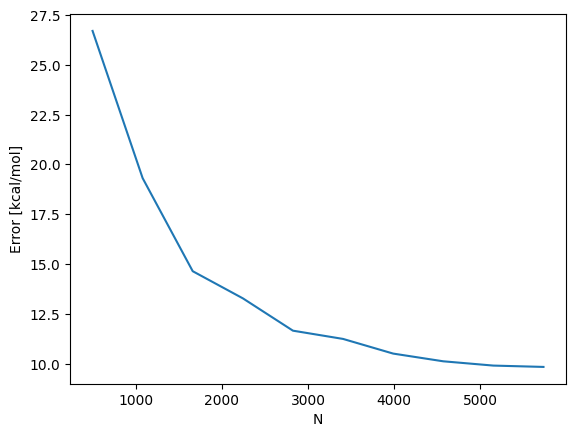

In [124]:
maes = []
train_sizes = np.linspace(500, len(y_train), 10, dtype=int)
for train_size in train_sizes:
    X_run = X_train[0:train_size]
    y_run = y_train[0:train_size]

    model = KernelRidge(kernel="rbf", alpha=1e-5, gamma=1e-3)

    model.fit(X_run, y_run)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    maes.append(mae)

    print(f"Train size: {train_size}, Test MAE: {mae} kcal/mol")
plt.plot(train_sizes, maes)
plt.xlabel("N")
plt.ylabel("Error [kcal/mol]")